In [2]:
import pandas as pd

df = pd.read_csv('cleanned.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
df.info()

df.head()

Shape: (918, 11)

Columns:
 Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'num'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   cp        918 non-null    object 
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    bool   
 6   restecg   918 non-null    object 
 7   thalch    918 non-null    float64
 8   exang     918 non-null    bool   
 9   oldpeak   918 non-null    float64
 10  num       918 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.5+ KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


In [3]:
# Convert to binary (0 = no disease, 1 = disease)
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

df.drop('num', axis=1, inplace=True)

print(df['target'].value_counts())

target
1    508
0    410
Name: count, dtype: int64


In [4]:
df = pd.get_dummies(df, drop_first=True)

print("Total columns:", len(df.columns))
print(df.columns)

df.head()

Total columns: 13
Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'target', 'sex_Male', 'cp_non-anginal', 'cp_typical angina',
       'restecg_normal', 'restecg_st-t abnormality'],
      dtype='object')


,age,trestbps,chol,fbs,thalch,exang,oldpeak,target,sex_Male,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,145.0,233.0,True,150.0,False,2.3,0,True,False,True,False,False
1,67,160.0,286.0,False,108.0,True,1.5,1,True,False,False,False,False
2,67,120.0,229.0,False,129.0,True,2.6,1,True,False,False,False,False
3,37,130.0,250.0,False,187.0,False,3.5,0,True,True,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0,False,False,True,False,False


In [5]:
df = df.astype(int)

df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,target,sex_Male,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,145,233,1,150,0,2,0,1,0,1,0,0
1,67,160,286,0,108,1,1,1,1,0,0,0,0
2,67,120,229,0,129,1,2,1,1,0,0,0,0
3,37,130,250,0,187,0,3,0,1,1,0,1,0
4,41,130,204,0,172,0,1,0,0,0,1,0,0


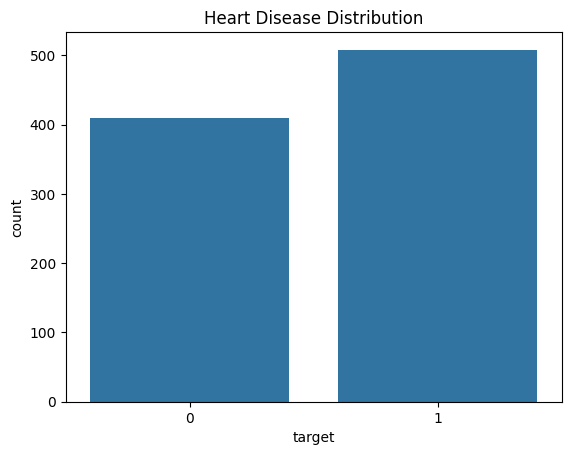

target
1    508
0    410
Name: count, dtype: int64


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

print(df['target'].value_counts())

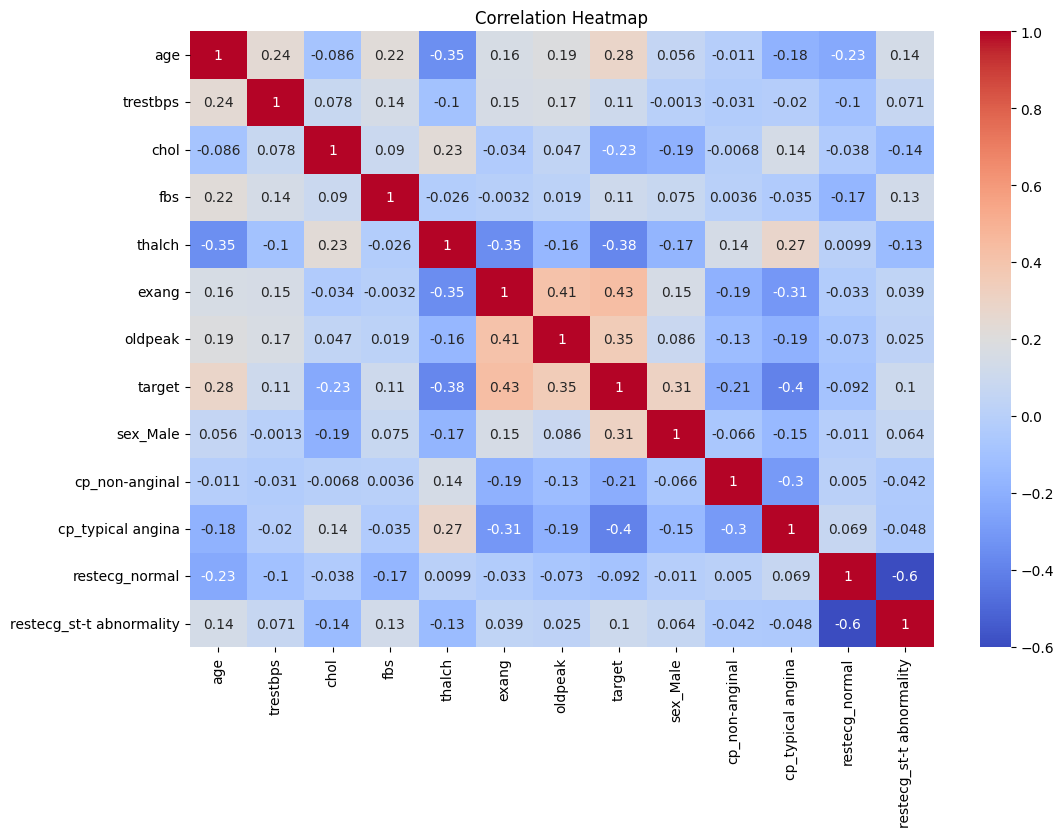

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

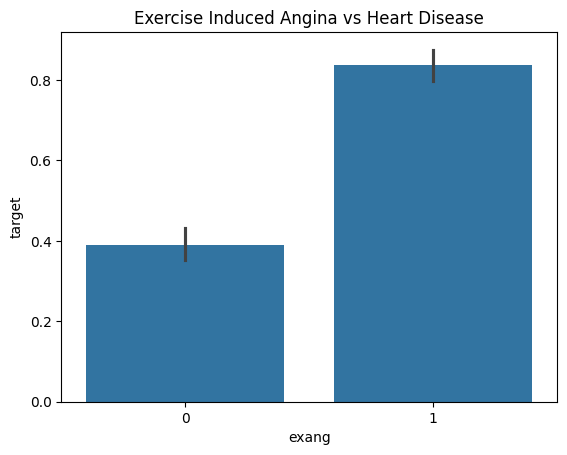

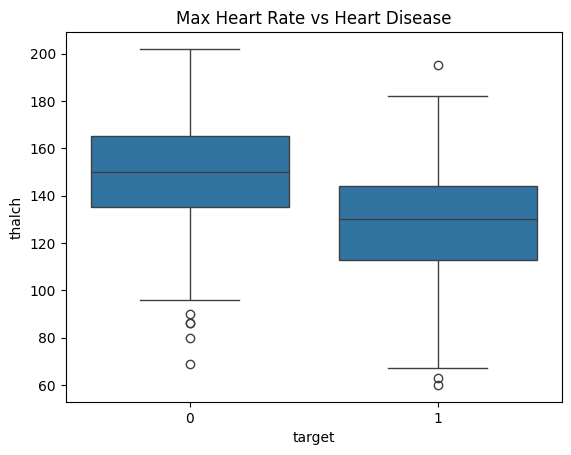

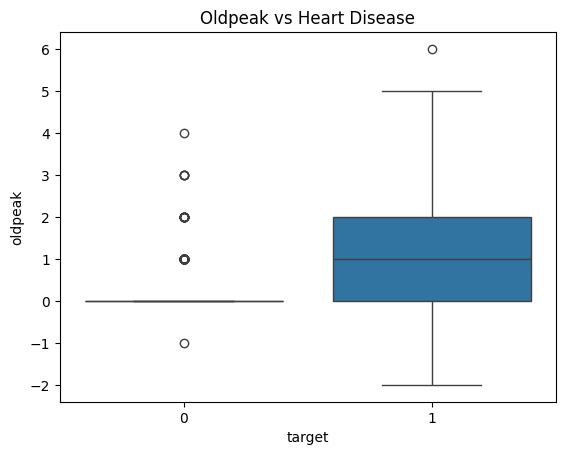

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# exang vs target
sns.barplot(x='exang', y='target', data=df)
plt.title("Exercise Induced Angina vs Heart Disease")
plt.show()

# thalch vs target
sns.boxplot(x='target', y='thalch', data=df)
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

# oldpeak vs target
sns.boxplot(x='target', y='oldpeak', data=df)
plt.title("Oldpeak vs Heart Disease")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (734, 12)
Test shape: (184, 12)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.8043478260869565


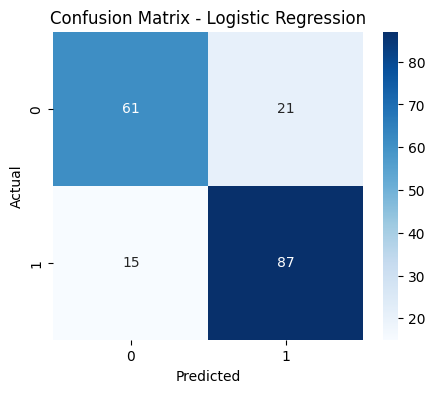

[[61 21]
 [15 87]]


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(cm)

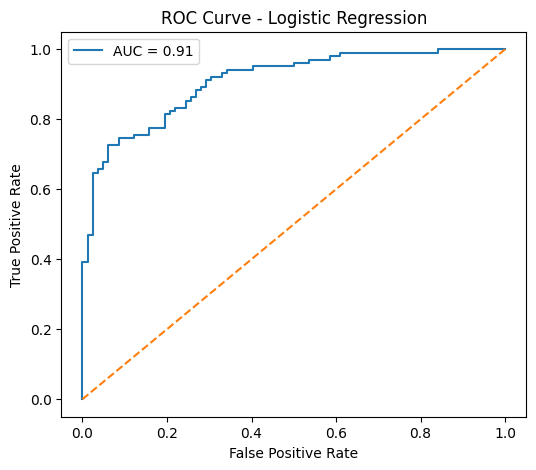

AUC Score: 0.9079387852702056


In [13]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.7282608695652174


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_tuned.fit(X_train, y_train)

y_pred_dt2 = dt_tuned.predict(X_test)

acc_dt2 = accuracy_score(y_test, y_pred_dt2)

print("Tuned Decision Tree Accuracy:", acc_dt2)

Tuned Decision Tree Accuracy: 0.7989130434782609


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8206521739130435


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_final.fit(X_train, y_train)

y_pred_rf_final = rf_final.predict(X_test)

acc_rf_final = accuracy_score(y_test, y_pred_rf_final)

print("Final Random Forest Accuracy:", acc_rf_final)

Final Random Forest Accuracy: 0.8260869565217391


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_final = LogisticRegression(
    max_iter=3000,
    C=0.5,
    solver='liblinear'
)

lr_final.fit(X_train_scaled, y_train)

y_pred_lr_final = lr_final.predict(X_test_scaled)

acc_lr_final = accuracy_score(y_test, y_pred_lr_final)

print("Final Logistic Regression Accuracy:", acc_lr_final)

Final Logistic Regression Accuracy: 0.8097826086956522


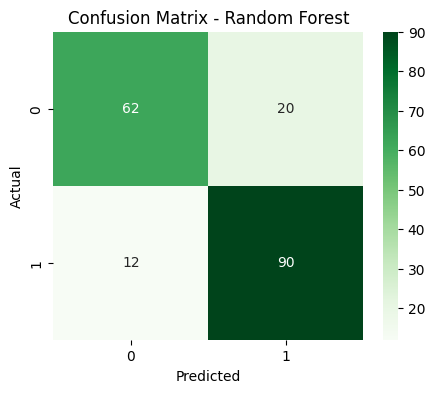

Random Forest CM:
 [[62 20]
 [12 90]]


In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf_final)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Random Forest CM:\n", cm_rf)

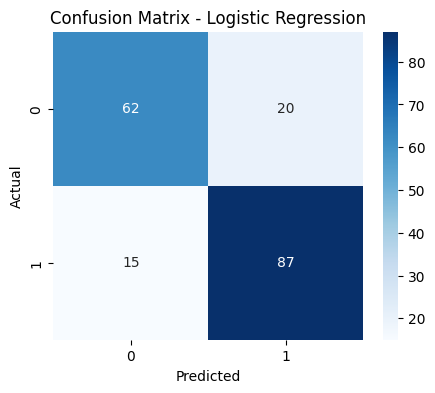

Logistic Regression CM:
 [[62 20]
 [15 87]]


In [20]:
cm_lr = confusion_matrix(y_test, y_pred_lr_final)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Logistic Regression CM:\n", cm_lr)

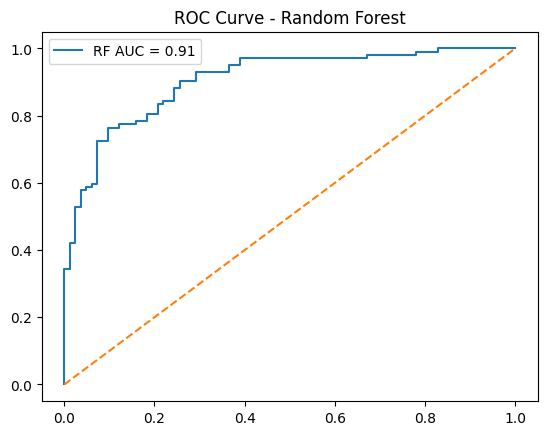

Random Forest AUC: 0.905428024868484


In [21]:
from sklearn.metrics import roc_curve, auc

rf_prob = rf_final.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = auc(fpr_rf, tpr_rf)

plt.plot(fpr_rf, tpr_rf, label=f"RF AUC = {auc_rf:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("Random Forest AUC:", auc_rf)

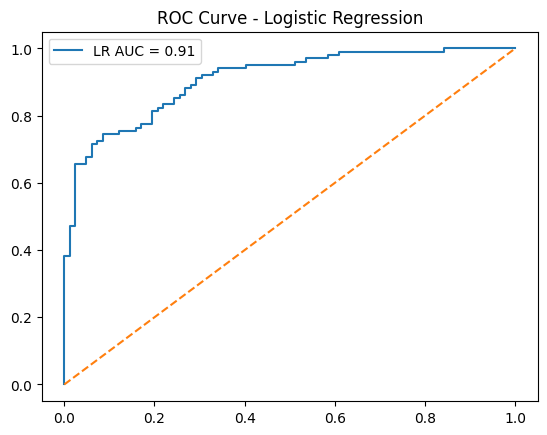

Logistic Regression AUC: 0.9075801052128168


In [22]:
lr_prob = lr_final.predict_proba(X_test_scaled)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
auc_lr = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, label=f"LR AUC = {auc_lr:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("Logistic Regression AUC:", auc_lr)

In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.8043478260869565
Decision Tree Accuracy: 0.7282608695652174


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling (for BOTH models to make fair comparison)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    solver='liblinear',
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [34]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

In [35]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.8043478260869565
Decision Tree Accuracy: 0.7880434782608695


In [36]:
from sklearn.metrics import confusion_matrix

print("\nLogistic Regression Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

print("\nDecision Tree Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))


Logistic Regression Confusion Matrix:

[[64 18]
 [18 84]]

Decision Tree Confusion Matrix:

[[63 19]
 [20 82]]


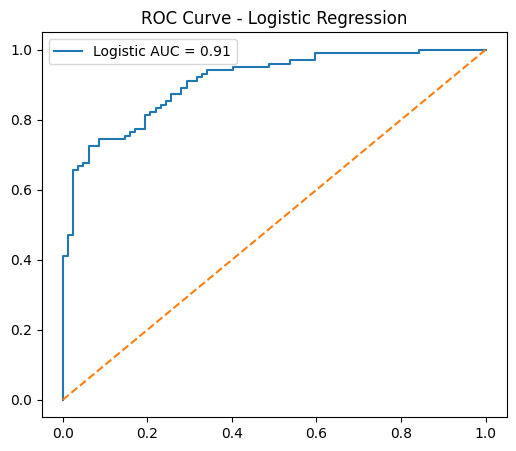

AUC Score: 0.9081779053084648


In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [38]:
import pickle
from sklearn.metrics import accuracy_score

# calculate accuracies
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Logistic Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)

# choose best model
if lr_acc >= dt_acc:
    best_model = lr
    model_name = "Logistic Regression"
else:
    best_model = dt
    model_name = "Decision Tree"

print("Best Model Selected:", model_name)

# save model
pickle.dump(best_model, open("model.pkl", "wb"))

# save scaler ONLY (needed for logistic regression)
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and scaler saved successfully!")

Logistic Accuracy: 0.8043478260869565
Decision Tree Accuracy: 0.7880434782608695
Best Model Selected: Logistic Regression
Model and scaler saved successfully!


In [39]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>